# **City Landscape in Sight: A Crowdsourced Framework for Unlocking Urban-Scale Window View Perceptions from Real Estate Imagery**

**Authors:** [Chucai Peng](https://ual.sg/author/chucai-peng/)†, [Sijie Yang](https://sijie-yang.com)†, Ang Liu, Yang Xiang, Zhixiang Zhou, [Filip Biljecki](https://filipbiljecki.com)* 

by [Urban Analytics Lab](https://ual.sg), [Department of Architecture](https://cde.nus.edu.sg/arch/), [College of Design and Engineering](https://cde.nus.edu.sg), [National University of Singapore](https://www.nus.edu.sg)


---

(† co-first authors, * corresponding authors)

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

# Code_6_WVI Perception Inference Analytics

This notebook benchmarks multiple regression models for predicting WVI perception scores from geospatial and visual features, evaluates their performance using R² and RMSE, checks multicollinearity (Spearman correlation and VIF), and analyses feature attributions with SHAP.

Data source used in this notebook:
- `data/data.csv` (perception and geospatial features for each WVI)

## 0. Plotting Configuration

Run plotting configuration first - Set up the overall style of figures.

In [4]:
import matplotlib as mpl
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=0.9)

mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "figure.autolayout": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.linewidth": 0.6,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "legend.fontsize": 7,
    "legend.frameon": False,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

OKABE_ITO = [
    "#E69F00",
    "#56B4E9",
    "#009E73",
    "#F0E442",
    "#0072B2",
    "#D55E00",
    "#CC79A7",
    "#000000",
]
sns.set_palette(OKABE_ITO)

INCH_PER_MM = 1.0 / 25.4
COL_WIDTH = 89 * INCH_PER_MM
DOUBLE_COL_WIDTH = 183 * INCH_PER_MM
FIG_HEIGHT_SMALL = 2.2
FIG_HEIGHT_MEDIUM = 2.8
FIG_HEIGHT_TALL = 3.4

from pathlib import Path

def savefig_all(fig, basename, png_dpi=300, tight=True):
    out_base = Path(basename)
    kwargs = {"bbox_inches": "tight", "pad_inches": 0.01} if tight else {}
    fig.savefig(str(out_base.with_suffix(".png")), dpi=png_dpi, **kwargs)
    fig.savefig(str(out_base.with_suffix(".svg")), **kwargs)

## 1. Inference Modelling
#### Load data

In [6]:
import pandas as pd

df = pd.read_csv('data/data_final_rescaled.csv')

perception_cols = ['Prefer', 'Monotonous', 'Quiet', 'Extensive', 'Vivid', 'Oppressive']
feature_cols = [
    'WV_Sky', 'WV_Highrisebuilding', 'WV_Lowrisebuilding', 'WV_Grass', 'WV_Hardground',
    'WV_Tree', 'WV_Water', 'WV_Railing', 'WV_Road', 'WV_Barrenland', 'WV_Buildinginterior',
    'LC_Water', 'LC_Trees', 'LC_Crops', 'LC_Built_Area', 'LC_Bare_Ground', 'LC_Rangeland',
    'BD', 'FAR', 'BH', 'BH_SD', 'NDBI', 'NDVI'
]

Y = df[perception_cols]
X = df[feature_cols]

print(f"Dataset: {len(df)} samples, {len(feature_cols)} features, {len(perception_cols)} targets")
print(f"Features: {feature_cols}")
print(f"\nY descriptive statistics:")
print(Y.describe().T.to_string())

Dataset: 12334 samples, 23 features, 6 targets
Features: ['WV_Sky', 'WV_Highrisebuilding', 'WV_Lowrisebuilding', 'WV_Grass', 'WV_Hardground', 'WV_Tree', 'WV_Water', 'WV_Railing', 'WV_Road', 'WV_Barrenland', 'WV_Buildinginterior', 'LC_Water', 'LC_Trees', 'LC_Crops', 'LC_Built_Area', 'LC_Bare_Ground', 'LC_Rangeland', 'BD', 'FAR', 'BH', 'BH_SD', 'NDBI', 'NDVI']

Y descriptive statistics:
              count      mean       std  min       25%       50%       75%  max
Prefer      12334.0  2.553117  1.382180  0.0  1.365947  2.378864  3.740006  5.0
Monotonous  12334.0  3.117624  1.126329  0.0  2.262482  3.162607  4.004495  5.0
Quiet       12334.0  2.633432  1.186936  0.0  1.699660  2.508832  3.467409  5.0
Extensive   12334.0  2.756291  1.294637  0.0  1.683228  2.702857  3.825074  5.0
Vivid       12334.0  2.452056  1.306857  0.0  1.358744  2.201761  3.446829  5.0
Oppressive  12334.0  3.000470  1.195202  0.0  2.063735  3.099299  3.931414  5.0


#### Multicollinearity — Spearman Correlation & VIF

Before fitting inference models, we examine pairwise associations among the 23 built-environment predictors using **Spearman rank correlation** and **Variance Inflation Factor (VIF)**.

**VIF is reported twice:**
1. **All 23 predictors** — includes all window-view (`WV_*`) and land-cover (`LC_*`) proportion classes. Because each group sums to ≈1 (compositional data), VIF is artificially inflated to very large values.
2. **Reference-dropped sets** — standard compositional practice: drop one class per group (`WV_Sky`, `LC_Water`) before VIF, then report subgroup tables for WV, LC, urban form, and the combined 21-feature inference set used conceptually in Table 8.

Variables with VIF > 5 indicate problematic multicollinearity for **OLS**; we therefore use regularised and ensemble methods (Ridge, Lasso, Random Forest, XGBoost) in the benchmark below (Reviewer 1, comment [8]).



Spearman correlation matrix: 29 × 29
|ρ| ≥ 0.7 pairs: 10
 feature_a           feature_b  spearman_rho
    Prefer           Extensive         0.869
        BH               BH_SD         0.852
       FAR                  BH         0.849
        BD                 FAR         0.808
  LC_Water       LC_Built_Area        -0.794
 Extensive              WV_Sky         0.792
    Prefer              WV_Sky         0.777
 Extensive          Oppressive        -0.728
    Prefer          Oppressive        -0.719
Oppressive WV_Highrisebuilding         0.715


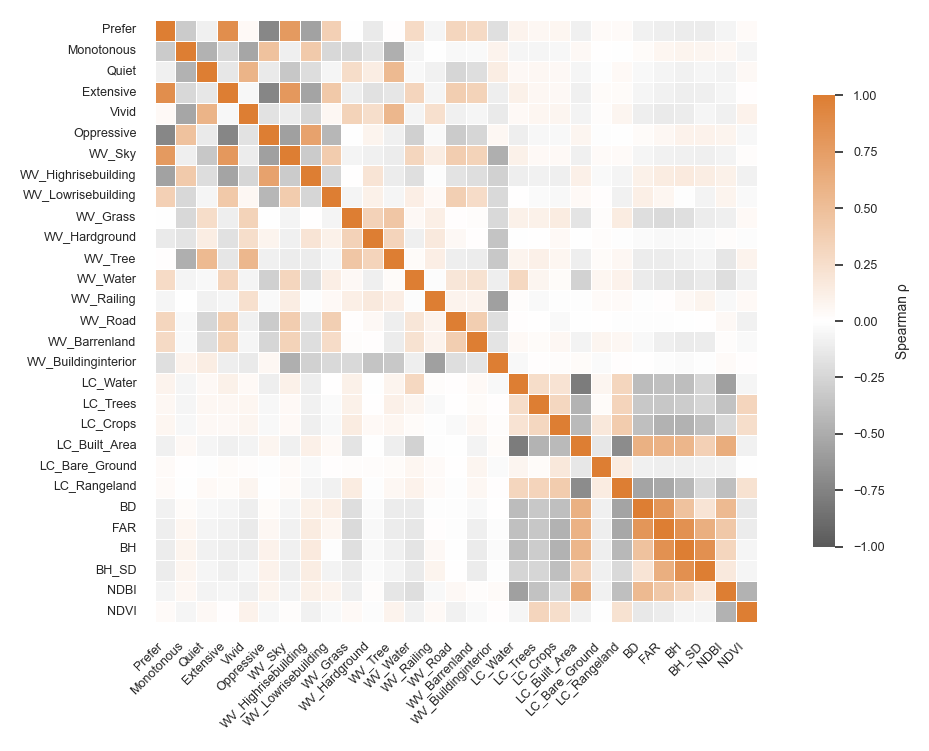

In [20]:
corr_cols = perception_cols + feature_cols
spearman_corr = df[corr_cols].corr(method='spearman')

out_dir = Path('model_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
spearman_corr.to_csv(out_dir / 'inference_spearman_correlation.csv')

# Strong pairwise correlations (|ρ| ≥ 0.7), upper triangle only
strong_pairs = []
for i, col_i in enumerate(corr_cols):
    for j in range(i + 1, len(corr_cols)):
        col_j = corr_cols[j]
        rho = spearman_corr.loc[col_i, col_j]
        if abs(rho) >= 0.7:
            strong_pairs.append({'feature_a': col_i, 'feature_b': col_j, 'spearman_rho': rho})

strong_corr_df = pd.DataFrame(strong_pairs).sort_values('spearman_rho', key=abs, ascending=False)
print(f'Spearman correlation matrix: {spearman_corr.shape[0]} × {spearman_corr.shape[1]}')
print(f'|ρ| ≥ 0.7 pairs: {len(strong_corr_df)}')
if len(strong_corr_df):
    print(strong_corr_df.to_string(index=False, float_format='%.3f'))

# Custom diverging colormap: negative -> grey, zero -> white, positive -> orange
from matplotlib.colors import LinearSegmentedColormap
CORR_NEG_COLOR = '#5A5A5A'
CORR_MID_COLOR = '#FFFFFF'
CORR_POS_COLOR = '#DD7E33'
corr_cmap = LinearSegmentedColormap.from_list(
    'corr_cmap', [CORR_NEG_COLOR, CORR_MID_COLOR, CORR_POS_COLOR])

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_TALL * 1.15))
sns.heatmap(
    spearman_corr,
    cmap=corr_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.25,
    cbar_kws={'label': 'Spearman ρ', 'shrink': 0.75},
    ax=ax,
)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=4.5)
cbar.set_label('Spearman ρ', fontsize=5)
# ax.set_title('Spearman correlation among inference predictors', fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=4.5)
plt.yticks(rotation=0, fontsize=4.5)
savefig_all(fig, 'figures/code_6_spearman_correlation')


Compositional constraint (row sums ≈ 1):
  WV (11 classes): mean sum = 1.0000
  LC (6 classes): mean sum = 1.0000

VIF — all 23 predictors (compositional inflation expected)
            feature        VIF  high_vif
             WV_Sky 2093242.99      True
WV_Highrisebuilding 2178873.30      True
 WV_Lowrisebuilding  199459.67      True
           WV_Grass   71887.45      True
      WV_Hardground  102644.86      True
            WV_Tree  902563.74      True
           WV_Water   23343.97      True
         WV_Railing  969940.86      True
            WV_Road   36037.61      True
      WV_Barrenland   24272.84      True
WV_Buildinginterior 5522937.90      True
           LC_Water   12565.76      True
           LC_Trees    1140.67      True
           LC_Crops    2084.60      True
      LC_Built_Area   22902.66      True
     LC_Bare_Ground      12.62      True
       LC_Rangeland    3476.27      True
                 BD       9.49     False
                FAR      24.62      True
      

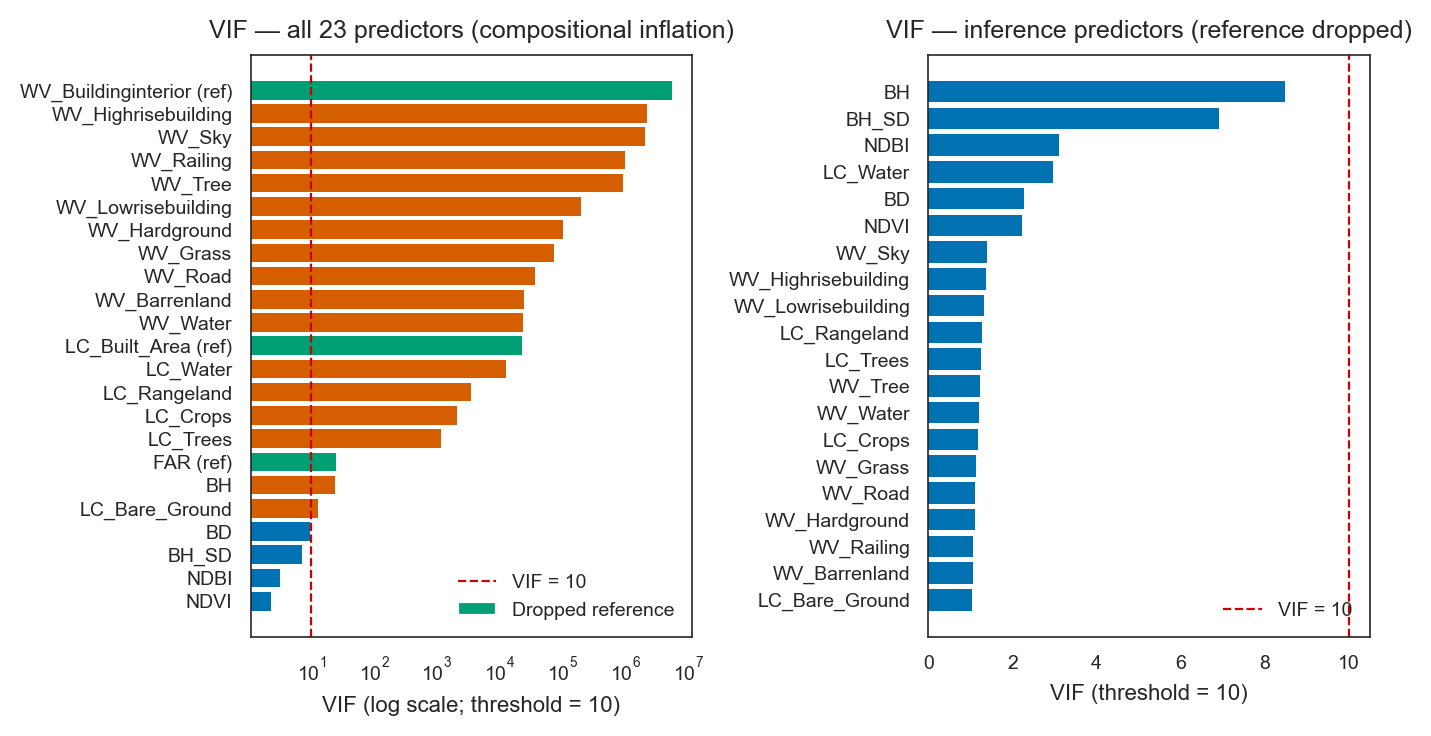

In [12]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF_THRESHOLD = 10
WV_COLS = [c for c in feature_cols if c.startswith('WV_')]
LC_COLS = [c for c in feature_cols if c.startswith('LC_')]
URBAN_COLS = ['BD', 'FAR', 'BH', 'BH_SD', 'NDBI', 'NDVI']
WV_REF = 'WV_Buildinginterior'
LC_REF = 'LC_Built_Area'
URBAN_REF = 'FAR'  # highest-VIF urban-form variable, used as the dropped reference


def compute_vif_df(cols, *, vif_set, dropped_reference=''):
    """VIF for a numeric predictor block (list preserves column order).

    A constant column is added before computing VIF: without an intercept,
    ``variance_inflation_factor`` regresses through the origin and grossly
    inflates the VIF of variables with large non-zero means (e.g. the
    dominant compositional classes). With the intercept, the VIF reflects
    genuine collinearity among the centred predictors.
    """
    cols = list(cols)
    X_sub = sm.add_constant(X[cols].astype(float), has_constant='add')
    # Column 0 is the constant; report VIF for the predictors at indices 1..k.
    vifs = [variance_inflation_factor(X_sub.values, i + 1) for i in range(len(cols))]
    return pd.DataFrame({
        'vif_set': vif_set,
        'feature': cols,
        'VIF': vifs,
        'high_vif': [v > VIF_THRESHOLD for v in vifs],
        'dropped_reference': dropped_reference,
    })


print('Compositional constraint (row sums ≈ 1):')
print(f"  WV ({len(WV_COLS)} classes): mean sum = {X[WV_COLS].sum(axis=1).mean():.4f}")
print(f"  LC ({len(LC_COLS)} classes): mean sum = {X[LC_COLS].sum(axis=1).mean():.4f}")

wv_cols = [c for c in WV_COLS if c != WV_REF]
lc_cols = [c for c in LC_COLS if c != LC_REF]
urban_cols = [c for c in URBAN_COLS if c != URBAN_REF]
inference_ref_cols = wv_cols + lc_cols + urban_cols

vif_frames = [
    compute_vif_df(feature_cols, vif_set='all_23_predictors'),
    compute_vif_df(wv_cols, vif_set='wv_compositional', dropped_reference=WV_REF),
    compute_vif_df(lc_cols, vif_set='lc_compositional', dropped_reference=LC_REF),
    compute_vif_df(urban_cols, vif_set='urban_form', dropped_reference=URBAN_REF),
    compute_vif_df(
        inference_ref_cols,
        vif_set='inference_reference_dropped',
        dropped_reference=f'{WV_REF}; {LC_REF}',
    ),
]
vif_all = pd.concat(vif_frames, ignore_index=True)
vif_all.to_csv(out_dir / 'inference_vif.csv', index=False)

# --- Print tables ---
def print_vif_block(df, title):
    print(f'\n{title}')
    print(df[['feature', 'VIF', 'high_vif']].to_string(index=False, float_format='%.2f'))
    n_high = int(df['high_vif'].sum())
    print(f'  VIF > {VIF_THRESHOLD}: {n_high} / {len(df)}')

print_vif_block(
    vif_all[vif_all['vif_set'] == 'all_23_predictors'],
    'VIF — all 23 predictors (compositional inflation expected)',
)
print_vif_block(
    vif_all[vif_all['vif_set'] == 'wv_compositional'],
    f'VIF — window-view proportions (reference dropped: {WV_REF})',
)
print_vif_block(
    vif_all[vif_all['vif_set'] == 'lc_compositional'],
    f'VIF — land-cover proportions (reference dropped: {LC_REF})',
)
print_vif_block(
    vif_all[vif_all['vif_set'] == 'urban_form'],
    f'VIF — urban form / indices (reference dropped: {URBAN_REF})',
)
print_vif_block(
    vif_all[vif_all['vif_set'] == 'inference_reference_dropped'],
    f'VIF — combined inference set ({len(inference_ref_cols)} features; references dropped: {WV_REF}, {LC_REF}, {URBAN_REF})',
)


def plot_vif_barh(df, *, ax, title, log_scale=False, refs=None):
    from matplotlib.patches import Patch

    refs = set(refs or [])
    plot_df = df.sort_values('VIF', ascending=True)
    bar_colors = []
    for feat, v in zip(plot_df['feature'], plot_df['VIF']):
        if feat in refs:
            bar_colors.append('#009E73')          # dropped reference
        elif v > VIF_THRESHOLD:
            bar_colors.append('#D55E00')          # above threshold
        else:
            bar_colors.append('#0072B2')          # retained, below threshold
    ax.barh(plot_df['feature'], plot_df['VIF'], color=bar_colors, edgecolor='none')
    if refs:
        labels = [f'{feat} (ref)' if feat in refs else feat for feat in plot_df['feature']]
        ax.set_yticks(range(len(plot_df)))
        ax.set_yticklabels(labels)
    if log_scale:
        ax.set_xscale('log')
        xlabel = f'VIF (log scale; threshold = {VIF_THRESHOLD})'
    else:
        xlabel = f'VIF (threshold = {VIF_THRESHOLD})'
    handles = [ax.axvline(VIF_THRESHOLD, color='#CC0000', linestyle='--', linewidth=0.8, label=f'VIF = {VIF_THRESHOLD}')]
    if refs:
        handles.append(Patch(facecolor='#009E73', label='Dropped reference'))
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=9)
    ax.legend(handles=handles, loc='lower right', frameon=False)


fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(COL_WIDTH * 2, FIG_HEIGHT_TALL * 1.1))
plot_vif_barh(
    vif_all[vif_all['vif_set'] == 'all_23_predictors'],
    ax=ax_left,
    title='VIF — all 23 predictors (compositional inflation)',
    log_scale=True,
    refs=[WV_REF, LC_REF, URBAN_REF],
)
plot_vif_barh(
    vif_all[vif_all['vif_set'] == 'inference_reference_dropped'],
    ax=ax_right,
    title=f'VIF — inference predictors (reference dropped)',
    log_scale=False,
)
fig.tight_layout()
savefig_all(fig, 'figures/code_6_vif_barplot')
plt.show()



#### Model Regression Benchmark

We train and evaluate seven regression models: Ridge, Lasso, ElasticNet, PLS, Random Forest, SVR, and XGBoost.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Inference modelling uses the VIF-reduced predictor set: one reference per group
# is dropped (WV_Buildinginterior, LC_Built_Area, FAR) so the models are fit on
# predictors free of the structural compositional collinearity (all VIF < 10).
X_inf = df[inference_ref_cols]
print(f"Inference modelling on {X_inf.shape[1]} predictors after VIF reduction "
      f"(dropped: {WV_REF}, {LC_REF}, {URBAN_REF}).")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_inf)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.3, random_state=42
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Inference modelling on 20 predictors after VIF reduction (dropped: WV_Buildinginterior, LC_Built_Area, FAR).
Train: 8633 samples | Test: 3701 samples


In [14]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from tqdm import tqdm

steps = [
    ('Ridge',        lambda: Ridge(alpha=1.0)),
    ('Lasso',        lambda: Lasso(alpha=0.1)),
    ('ElasticNet',   lambda: ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ('PLS',          lambda: PLSRegression(n_components=min(10, X_train.shape[1]))),
    ('RandomForest', lambda: RandomForestRegressor(n_estimators=100, random_state=42)),
]

preds = {}
with tqdm(steps, desc='Training linear/ensemble models') as pbar:
    for name, model_fn in pbar:
        pbar.set_postfix(model=name)
        m = model_fn()
        m.fit(X_train, Y_train)
        preds[name] = m.predict(X_test)

Y_pred_ridge       = preds['Ridge']
Y_pred_lasso       = preds['Lasso']
Y_pred_elastic_net = preds['ElasticNet']
Y_pred_pls         = preds['PLS']
Y_pred_rf          = preds['RandomForest']

Y_pred_svr, Y_pred_xgb = [], []
targets = list(range(Y_train.shape[1]))
for i in tqdm(targets, desc='Training SVR & XGBoost per target'):
    svr = SVR(kernel='rbf')
    svr.fit(X_train, Y_train.iloc[:, i])
    Y_pred_svr.append(svr.predict(X_test))

    xgb_reg = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    xgb_reg.fit(X_train, Y_train.iloc[:, i])
    Y_pred_xgb.append(xgb_reg.predict(X_test))

Y_pred_svr = np.column_stack(Y_pred_svr)
Y_pred_xgb = np.column_stack(Y_pred_xgb)

print('All models trained.')

Training SVR & XGBoost per target: 100%|██████████| 6/6 [00:15<00:00,  2.66s/it]

All models trained.


#### Model Evaluation — R² and RMSE

In [15]:
from sklearn.metrics import r2_score, mean_squared_error

models = {
    'Ridge': Y_pred_ridge,
    'Lasso': Y_pred_lasso,
    'ElasticNet': Y_pred_elastic_net,
    'PLS': Y_pred_pls,
    'RandomForest': Y_pred_rf,
    'SVR': Y_pred_svr,
    'XGBoost': Y_pred_xgb,
}

r2_scores = pd.DataFrame(index=models.keys(), columns=perception_cols, dtype=float)
rmse_scores = pd.DataFrame(index=models.keys(), columns=perception_cols, dtype=float)

for model_name, Y_pred in models.items():
    for i, col in enumerate(perception_cols):
        y_true = Y_test[col]
        y_pred = Y_pred[:, i] if Y_pred.ndim == 2 else Y_pred
        r2_scores.loc[model_name, col] = r2_score(y_true, y_pred)
        rmse_scores.loc[model_name, col] = np.sqrt(mean_squared_error(y_true, y_pred))

print("R² Scores:")
print(r2_scores.astype(float).round(4).to_string())
print("\nRMSE Scores:")
print(rmse_scores.astype(float).round(4).to_string())

R² Scores:
              Prefer  Monotonous   Quiet  Extensive   Vivid  Oppressive
Ridge         0.7347      0.3859  0.4263     0.7514  0.3682      0.6833
Lasso         0.7117      0.3472  0.3721     0.7231  0.3127      0.6545
ElasticNet    0.7230      0.3685  0.4042     0.7387  0.3459      0.6682
PLS           0.7344      0.3853  0.4250     0.7514  0.3602      0.6842
RandomForest  0.7726      0.4564  0.5254     0.7888  0.5211      0.7194
SVR           0.7722      0.4572  0.5178     0.7860  0.5096      0.7215
XGBoost       0.7855      0.4788  0.5513     0.8027  0.5614      0.7379

RMSE Scores:
              Prefer  Monotonous   Quiet  Extensive   Vivid  Oppressive
Ridge         0.7108      0.8903  0.8867     0.6428  1.0364      0.6750
Lasso         0.7410      0.9179  0.9276     0.6784  1.0810      0.7049
ElasticNet    0.7262      0.9029  0.9036     0.6591  1.0546      0.6909
PLS           0.7112      0.8908  0.8877     0.6428  1.0429      0.6741
RandomForest  0.6581      0.8376  0.806

#### Model Visualisation — R² Heatmap

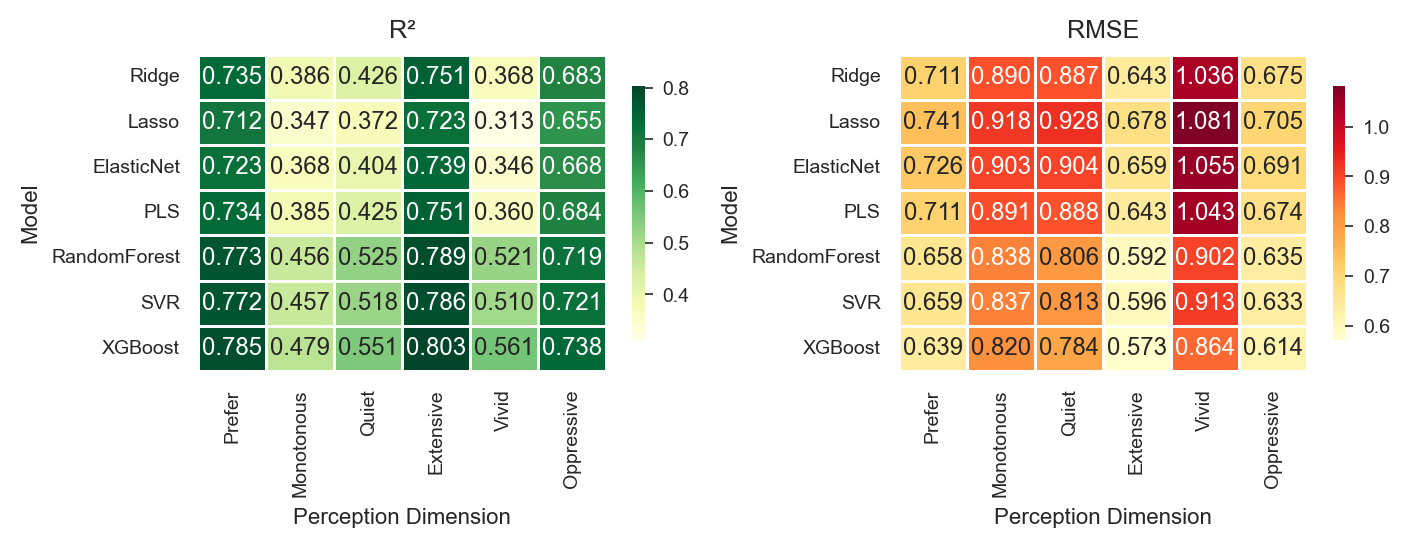

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_MEDIUM))

for ax, data, title in zip(axes,
                            [r2_scores.astype(float), rmse_scores.astype(float)],
                            ['R²', 'RMSE']):
    sns.heatmap(
        data,
        ax=ax,
        annot=True,
        fmt='.3f',
        cmap='YlOrRd' if title == 'RMSE' else 'YlGn',
        linewidths=0.4,
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(title)
    ax.set_xlabel('Perception Dimension')
    ax.set_ylabel('Model')

plt.tight_layout()
savefig_all(fig, 'figures/code_6_inference_model_heatmap')
plt.show()

## 2. SHAP Feature Attribution

XGBoost is fitted on the unscaled features (tree models are scale-invariant) for every perception dimension, and SHAP values are computed on the held-out test split.

#### Train XGBoost models and compute SHAP values

In [17]:
import shap

X_train_raw, X_test_raw, _, _ = train_test_split(
    X_inf, Y, test_size=0.3, random_state=42
)

shap_models = {}
explainers = {}
shap_values_dict = {}

for target in tqdm(perception_cols, desc='Training XGBoost & computing SHAP'):
    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective='reg:squarederror',
        random_state=42,
    )
    model.fit(X_train_raw, Y_train[target])
    shap_models[target] = model

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_raw)
    explainers[target] = explainer
    shap_values_dict[target] = shap_values

print(f"Computed SHAP values for {len(perception_cols)} perception dimensions on {X_test_raw.shape[0]} test samples.")

Training XGBoost & computing SHAP: 100%|██████████| 6/6 [00:03<00:00,  1.62it/s]

Computed SHAP values for 6 perception dimensions on 3701 test samples.


#### SHAP Summary Plots

A 3×2 grid of violin SHAP summary plots, one per perception dimension, showing the top 10 contributing features. The colour bar on the right of each row represents the feature value (low to high).

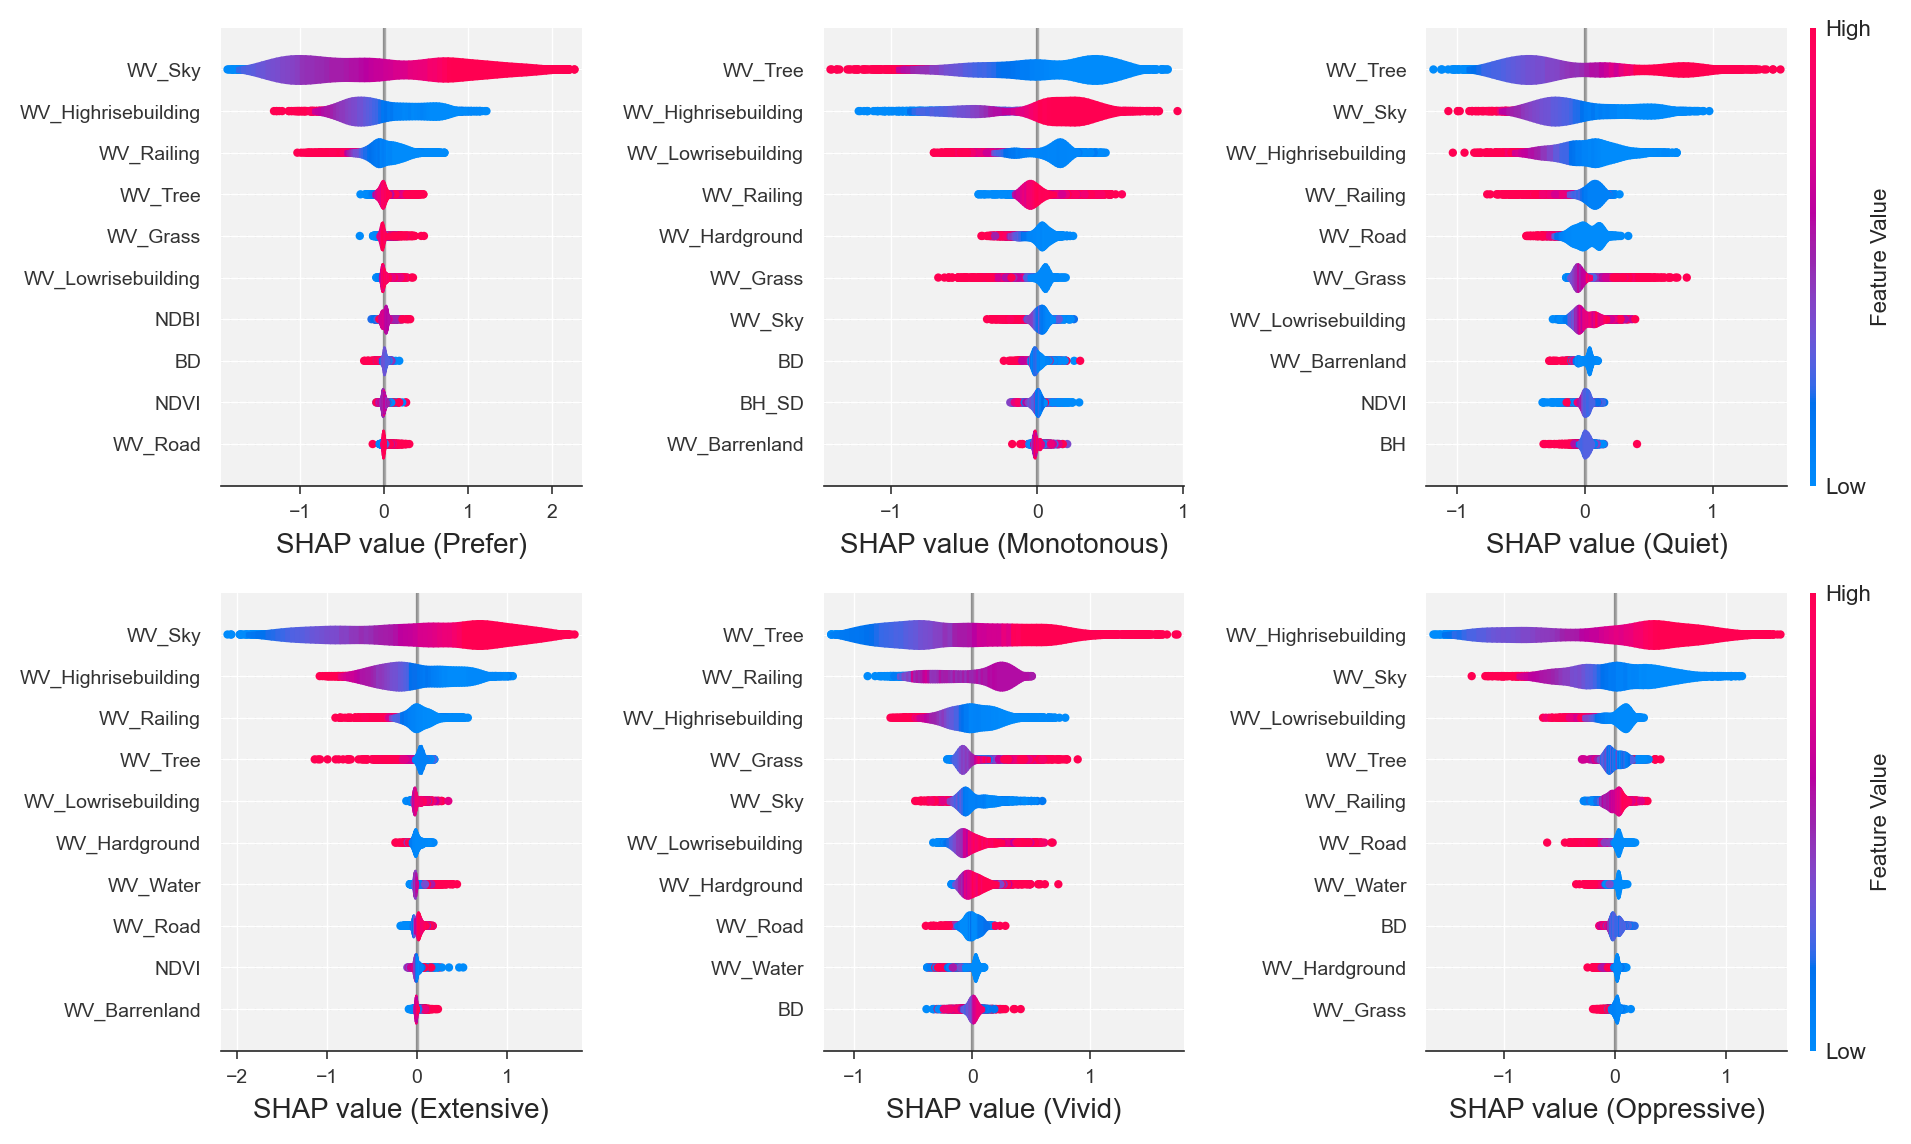

In [18]:
from matplotlib.ticker import MultipleLocator

fig = plt.figure(figsize=(DOUBLE_COL_WIDTH * 1.35, FIG_HEIGHT_TALL * 1.7))

for idx, target in enumerate(perception_cols):
    plt.subplot(2, 3, idx + 1)

    shap.summary_plot(
        shap_values_dict[target],
        X_test_raw,
        show=False,
        max_display=10,
        plot_size=None,
        plot_type='violin',
    )

    plt.xlabel(f'SHAP value ({target})', fontsize=10)

    for label in plt.gca().get_xticklabels():
        label.set_fontsize(7)
    for label in plt.gca().get_yticklabels():
        label.set_fontsize(7)

    ax = plt.gca()
    ax.set_facecolor('#F2F2F2')
    ax.set_axisbelow(True)
    ax.grid(True, which='major', axis='both', color='white', linewidth=0.5, alpha=1.0)
    ax.tick_params(axis='y', pad=5, length=2)
    ax.margins(x=0.02)
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.axvline(0, color='#888888', linewidth=0.6, zorder=0.7)

    if idx in (2, 5):
        colorbar = plt.gca().figure.axes[-1]
        colorbar.set_ylabel('Feature Value', fontsize=8)
        colorbar.set_yticklabels(['Low', 'High'], fontsize=8)
    else:
        plt.gca().get_figure().delaxes(plt.gca().figure.axes[-1])

plt.tight_layout(w_pad=0.3)
Path('figures').mkdir(exist_ok=True)
savefig_all(fig, 'figures/code_6_shap_summary')
plt.show()

#### SHAP Dependence with LOWESS — Computation

For every (perception, feature) pair, a LOWESS smoother is fitted to the SHAP values, and a 95% bootstrap confidence interval is estimated by resampling.

In [12]:
import statsmodels.api as sm
import pickle


def bootstrap_lowess(x, y, n_iterations=1000, frac=0.3, seed=42):
    """Compute a bootstrap confidence interval for a LOWESS smoother."""
    rng = np.random.default_rng(seed)
    n_samples = len(x)
    predictions = np.zeros((n_iterations, n_samples))
    x_range = x.max() - x.min()
    delta = 0.01 * x_range if x_range > 0 else 0.0

    for i in range(n_iterations):
        indices = rng.integers(0, n_samples, n_samples)
        x_sample = x[indices]
        y_sample = y[indices]

        sort_idx = np.argsort(x_sample)
        x_sorted = x_sample[sort_idx]
        y_sorted = y_sample[sort_idx]

        lowess_result = sm.nonparametric.lowess(
            y_sorted, x_sorted, frac=frac, it=1, delta=delta
        )
        predictions[i] = np.interp(x, lowess_result[:, 0], lowess_result[:, 1])

    ci_lower = np.percentile(predictions, 2.5, axis=0)
    ci_upper = np.percentile(predictions, 97.5, axis=0)
    return ci_lower, ci_upper


Path('figures').mkdir(exist_ok=True)
PKL_PATH = Path('figures/code_6_lowess_results.pkl')
if PKL_PATH.exists():
    with open(PKL_PATH, 'rb') as f:
        lowess_results = pickle.load(f)
    print(f'Loaded {len(lowess_results)} existing LOWESS results; will skip those.')
else:
    lowess_results = {}

total_pairs = len(perception_cols) * len(inference_ref_cols)
pbar = tqdm(total=total_pairs, desc='Computing LOWESS smoothers')
for target in perception_cols:
    shap_values = shap_values_dict[target]
    for feature in inference_ref_cols:
        pbar.set_postfix_str(f'{target} / {feature}')
        if (target, feature) in lowess_results:
            pbar.update(1)
            continue
        feature_idx_in_X = inference_ref_cols.index(feature)
        feature_values = X_test_raw[feature].values
        feature_shap_values = shap_values[:, feature_idx_in_X]

        sort_idx = np.argsort(feature_values)
        x_sorted = feature_values[sort_idx]
        y_sorted = feature_shap_values[sort_idx]

        x_range = x_sorted.max() - x_sorted.min()
        delta_main = 0.01 * x_range if x_range > 0 else 0.0
        lowess_result = sm.nonparametric.lowess(
            y_sorted, x_sorted, frac=0.3, it=1, delta=delta_main
        )
        x_lowess, y_lowess = lowess_result[:, 0], lowess_result[:, 1]
        ci_lower, ci_upper = bootstrap_lowess(x_sorted, y_sorted)

        lowess_results[(target, feature)] = {
            'x_sorted': x_sorted,
            'y_sorted': y_sorted,
            'x_lowess': x_lowess,
            'y_lowess': y_lowess,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
        }
        with open(PKL_PATH, 'wb') as f:
            pickle.dump(lowess_results, f)
        pbar.update(1)

pbar.close()

print(f"Stored LOWESS results for {len(lowess_results)} (perception, feature) pairs.")

Loaded 16 existing LOWESS results; will skip those.


Computing LOWESS smoothers:  22%|██▏       | 26/120 [00:24<02:50,  1.82s/it, Monotonous / WV_Water]           /Users/sijieyang/anaconda3/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
Computing LOWESS smoothers: 100%|██████████| 120/120 [03:50<00:00,  1.92s/it, Oppressive / NDVI]               

Stored LOWESS results for 120 (perception, feature) pairs.


#### SHAP Dependence with LOWESS — Visualisation

For each feature, a 2×3 grid shows the SHAP dependence plot across the six perception dimensions, overlaid with the LOWESS smoother and its 95% bootstrap confidence band.

In [1]:
# === Load precomputed LOWESS results (run this to skip the heavy SHAP/LOWESS steps) ===
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

INCH_PER_MM = 1.0 / 25.4
COL_WIDTH = 89 * INCH_PER_MM
DOUBLE_COL_WIDTH = 183 * INCH_PER_MM
FIG_HEIGHT_SMALL = 2.2
FIG_HEIGHT_MEDIUM = 2.8
FIG_HEIGHT_TALL = 3.4


def savefig_all(fig, basename, png_dpi=300, tight=True):
    out_base = Path(basename)
    kwargs = {"bbox_inches": "tight", "pad_inches": 0.01} if tight else {}
    fig.savefig(str(out_base.with_suffix(".png")), dpi=png_dpi, **kwargs)
    fig.savefig(str(out_base.with_suffix(".svg")), **kwargs)

perception_cols = ['Prefer', 'Monotonous', 'Quiet', 'Extensive', 'Vivid', 'Oppressive']

with open('figures/code_6_lowess_results.pkl', 'rb') as f:
    lowess_results = pickle.load(f)

# Reconstruct the feature lists (preserving their original order) from the loaded keys
all_features = []
for (_t, _feat) in lowess_results:
    if _feat not in all_features:
        all_features.append(_feat)
wv_cols = [c for c in all_features if c.startswith('WV_')]
lc_cols = [c for c in all_features if c.startswith('LC_')]
urban_cols = [c for c in all_features if not (c.startswith('WV_') or c.startswith('LC_'))]
inference_ref_cols = wv_cols + lc_cols + urban_cols

print(f'Loaded {len(lowess_results)} LOWESS results; '
      f'{len(wv_cols)} WV, {len(lc_cols)} LC, {len(urban_cols)} urban features.')

Loaded 120 LOWESS results; 10 WV, 5 LC, 5 urban features.


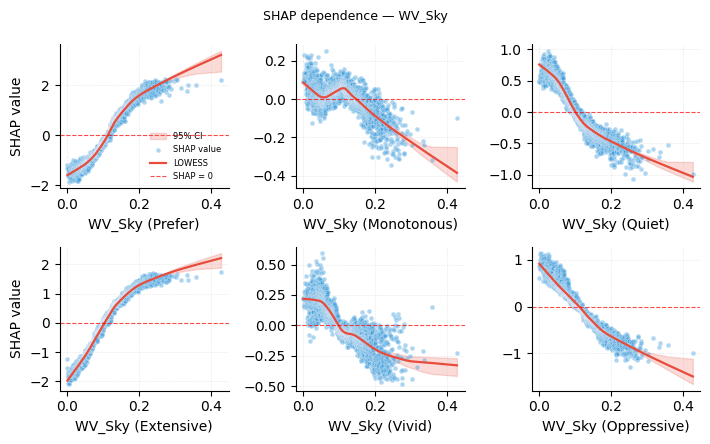

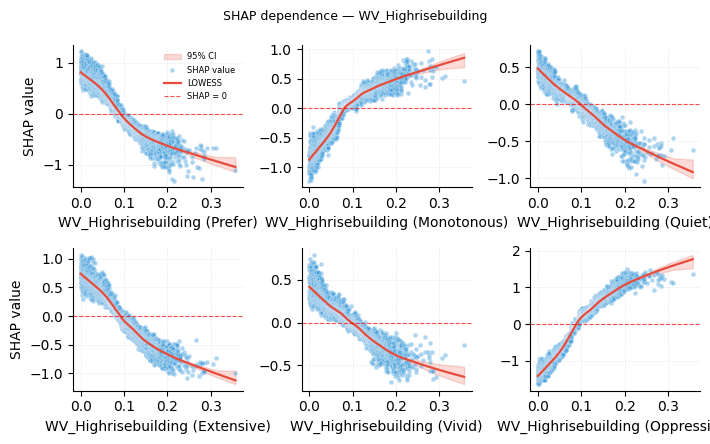

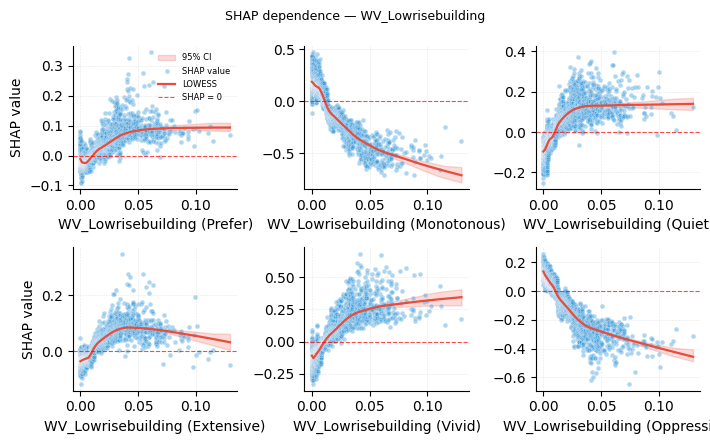

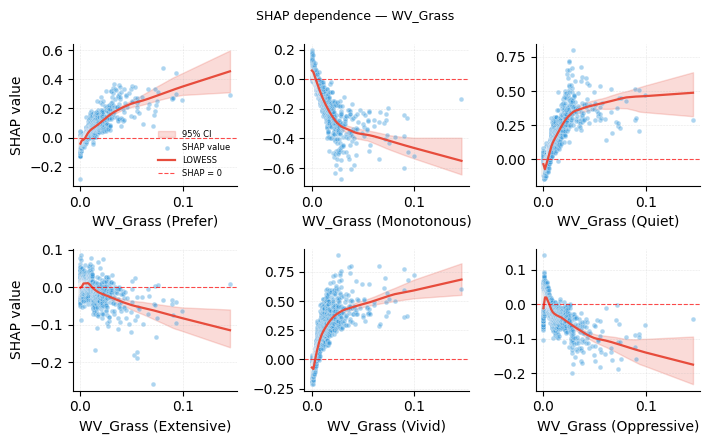

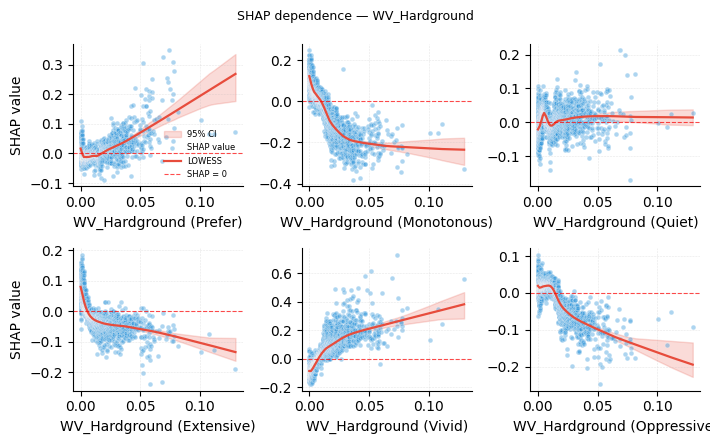

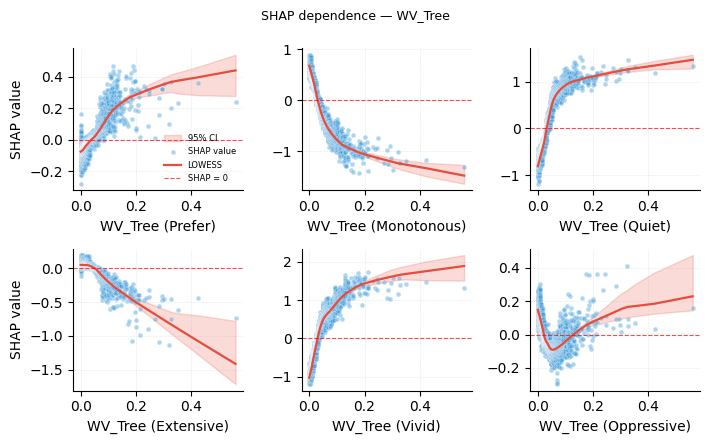

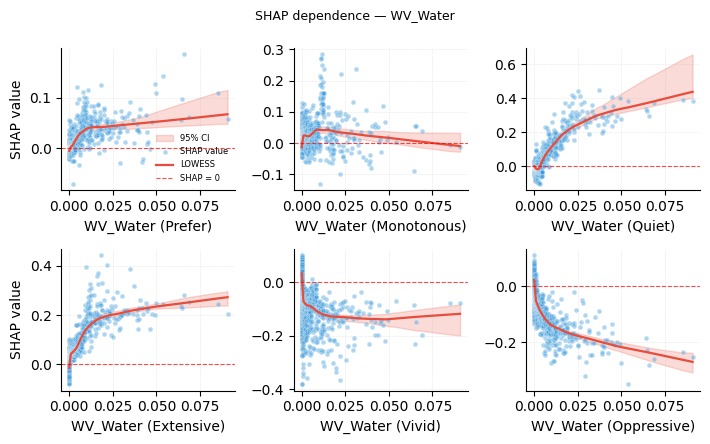

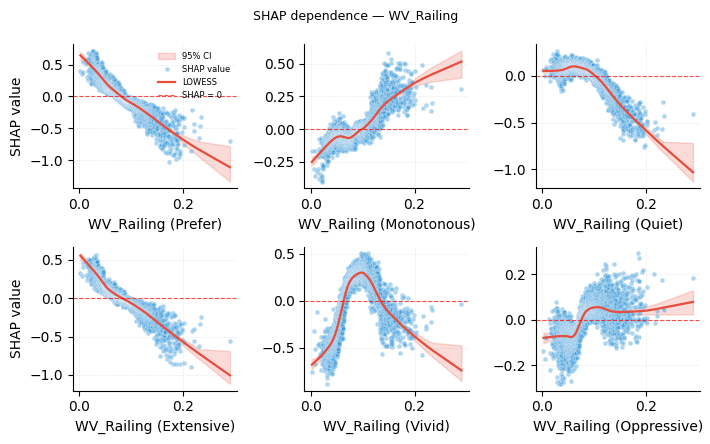

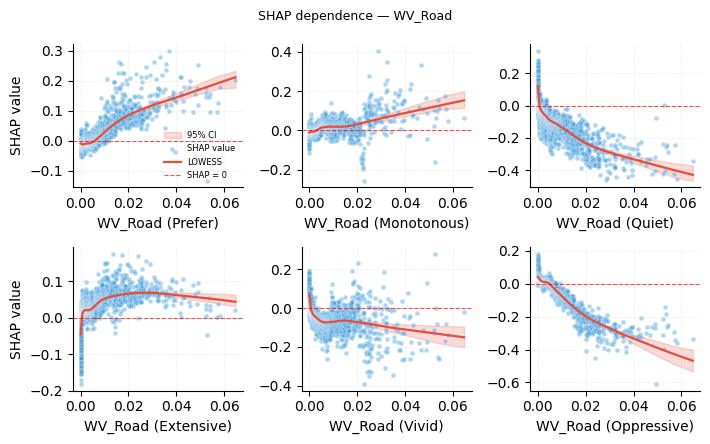

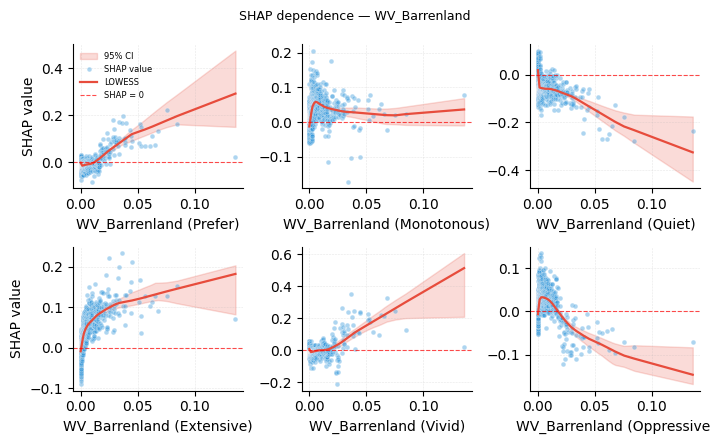

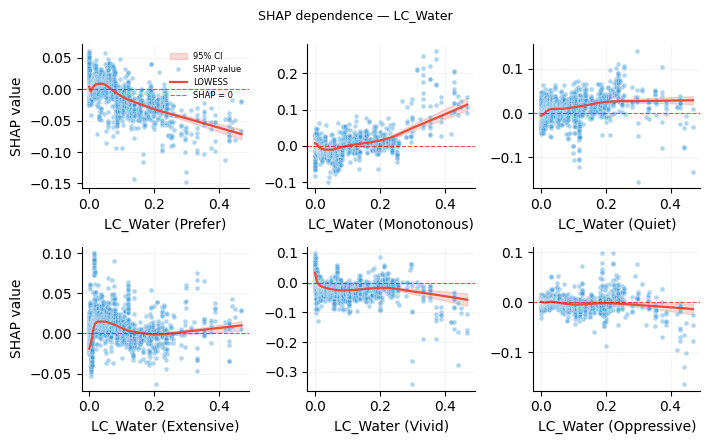

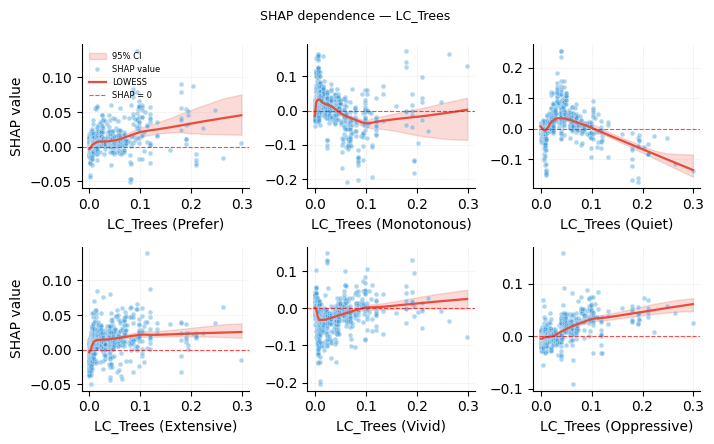

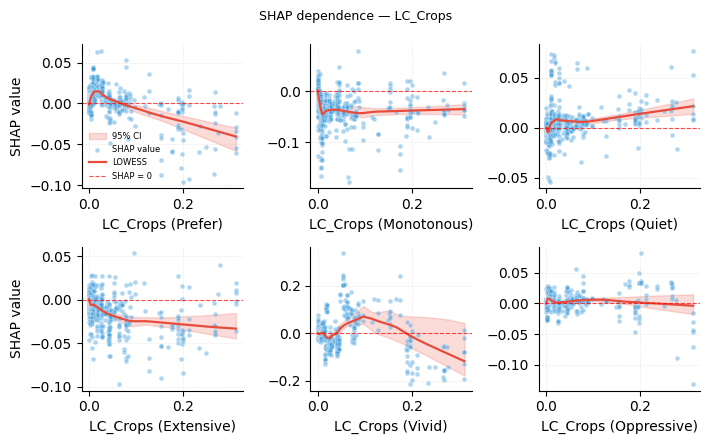

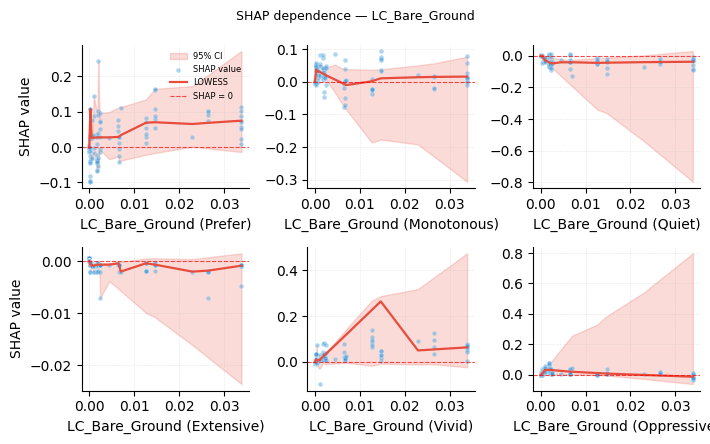

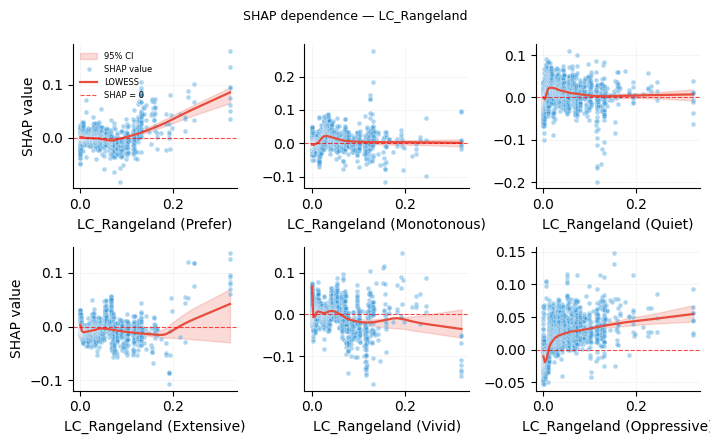

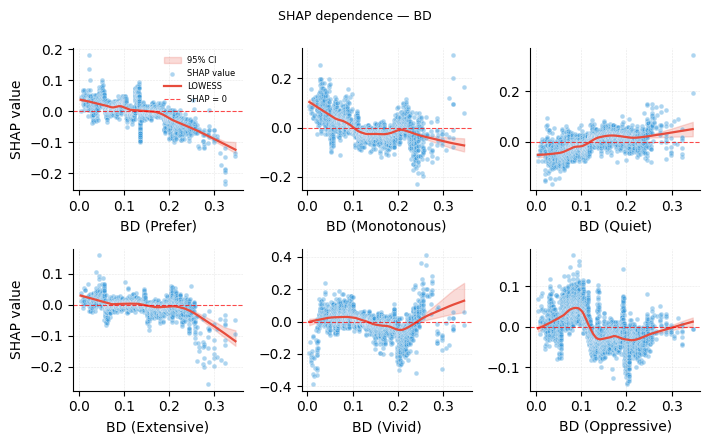

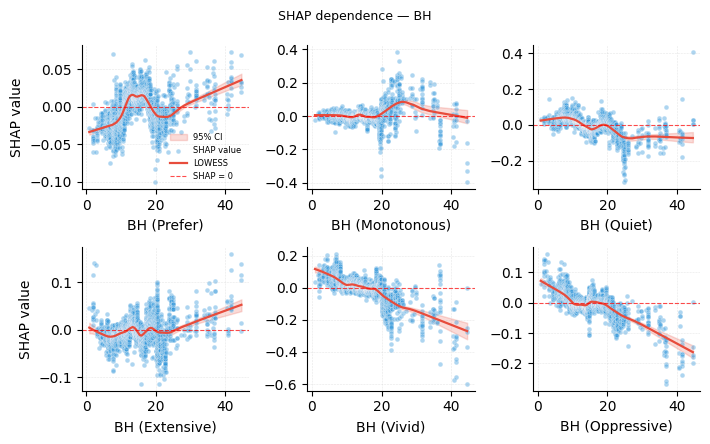

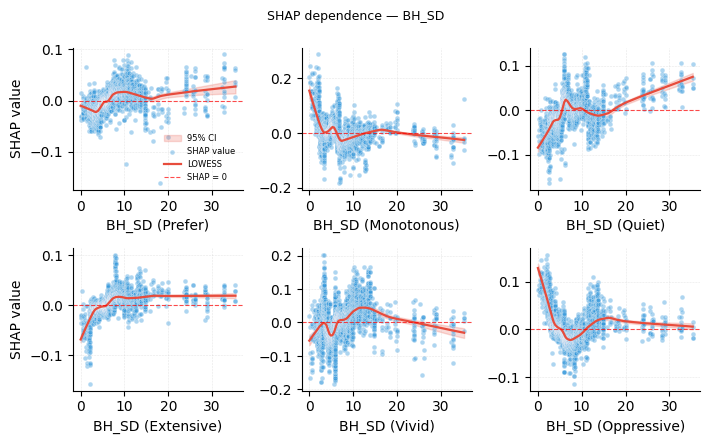

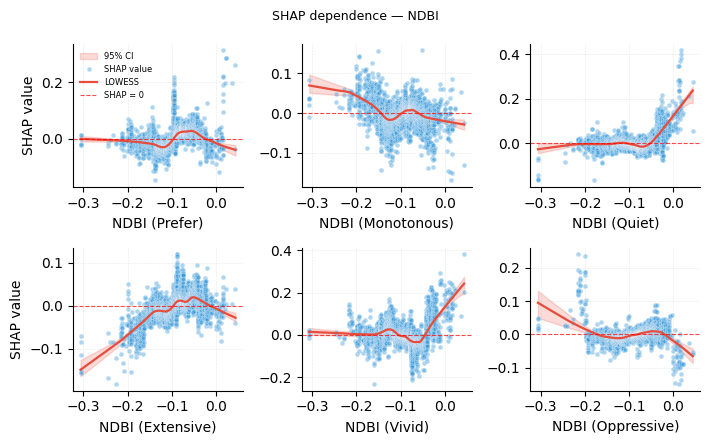

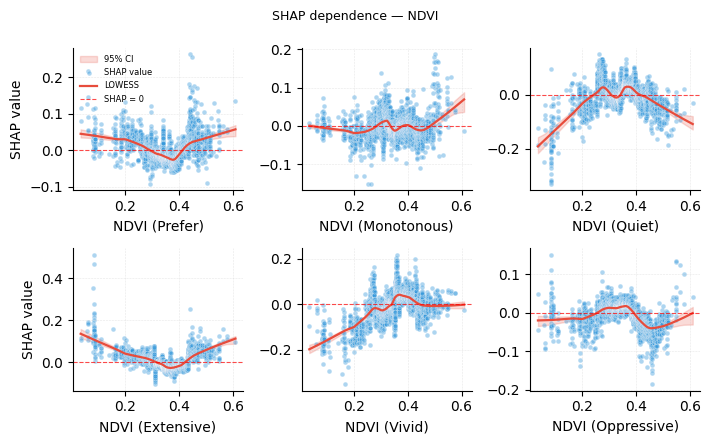

In [2]:
scatter_color = '#3498db'
line_color = '#e74c3c'
ci_color = '#e74c3c'

shap_fig_dir = Path('figures/code_6_shap_lowess')
shap_fig_dir.mkdir(parents=True, exist_ok=True)

for feature in inference_ref_cols:
    fig, axes = plt.subplots(
        2, 3, figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_MEDIUM * 1.6)
    )
    axes = axes.ravel()

    for idx, target in enumerate(perception_cols):
        ax = axes[idx]
        result = lowess_results[(target, feature)]
        x_sorted = result['x_sorted']
        y_sorted = result['y_sorted']
        x_lowess = result['x_lowess']
        y_lowess = result['y_lowess']
        ci_lower = result['ci_lower']
        ci_upper = result['ci_upper']

        ax.fill_between(
            x_sorted, ci_lower, ci_upper,
            color=ci_color, alpha=0.2, label='95% CI',
        )
        ax.scatter(
            x_sorted, y_sorted,
            alpha=0.4, s=12,
            c=scatter_color, edgecolor='white', linewidth=0.4,
            label='SHAP value',
        )
        ax.plot(
            x_lowess, y_lowess,
            color=line_color, linewidth=1.6, label='LOWESS',
        )
        ax.axhline(
            y=0, color='red', linestyle='--', linewidth=0.8,
            alpha=0.7, label='SHAP = 0',
        )

        ax.set_xlabel(f'{feature} ({target})')
        if idx % 3 == 0:
            ax.set_ylabel('SHAP value')

        ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if idx == 0:
            ax.legend(fontsize=6, frameon=False)

    fig.suptitle(f'SHAP dependence — {feature}', fontsize=9)
    plt.tight_layout()
    savefig_all(fig, str(shap_fig_dir / f'shap_lowess_{feature}'))
    plt.show()

Top SHAP feature per perception: {'Prefer': 'WV_Sky', 'Monotonous': 'WV_Tree', 'Quiet': 'WV_Tree', 'Extensive': 'WV_Sky', 'Vivid': 'WV_Tree', 'Oppressive': 'WV_Highrisebuilding'}


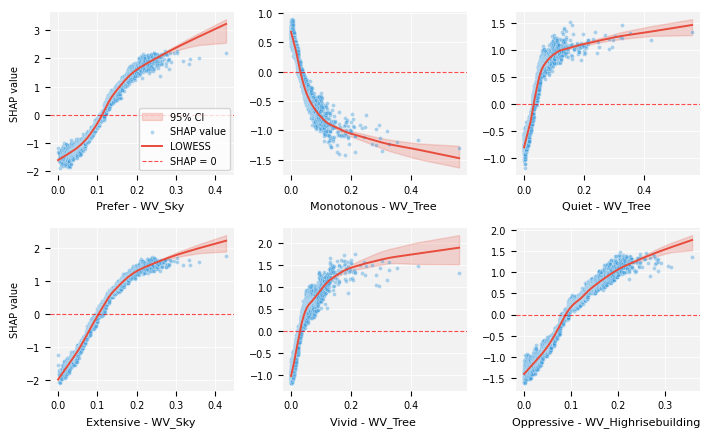

In [3]:
# Grouped LOWESS visualisations
scatter_color = '#3498db'
line_color = '#e74c3c'
ci_color = '#e74c3c'

group_fig_dir = Path('figures/code_6_shap_lowess_grouped')
group_fig_dir.mkdir(parents=True, exist_ok=True)


def plot_dependence(ax, target, feature, show_legend=False, show_ylabel=True, xlabel_fs=8, ylabel_fs=7, tick_fs=7, legend_fs=7):
    """Draw one SHAP-vs-feature LOWESS panel using precomputed lowess_results."""
    result = lowess_results[(target, feature)]
    x_sorted = result['x_sorted']
    y_sorted = result['y_sorted']
    x_lowess = result['x_lowess']
    y_lowess = result['y_lowess']
    ci_lower = result['ci_lower']
    ci_upper = result['ci_upper']

    ax.fill_between(x_sorted, ci_lower, ci_upper, color=ci_color, alpha=0.2, label='95% CI')
    ax.scatter(
        x_sorted, y_sorted, alpha=0.4, s=8,
        c=scatter_color, edgecolor='white', linewidth=0.3, label='SHAP value',
    )
    ax.plot(x_lowess, y_lowess, color=line_color, linewidth=1.4, label='LOWESS')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='SHAP = 0')

    ax.set_xlabel(f'{target} - {feature} ', fontsize=xlabel_fs)
    if show_ylabel:
        ax.set_ylabel('SHAP value', fontsize=ylabel_fs)
    ax.tick_params(labelsize=tick_fs)
    ax.set_facecolor('#F2F2F2')
    ax.set_axisbelow(True)
    ax.grid(True, which='major', color='white', linewidth=0.6, alpha=1.0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    if show_legend:
        ax.legend(fontsize=legend_fs, frameon=True)


# (1) Each perception with its most important (highest mean |SHAP|) feature
top_features = {}
for target in perception_cols:
    mean_abs = {feat: np.abs(lowess_results[(target, feat)]['y_sorted']).mean()
               for feat in inference_ref_cols}
    top_features[target] = max(mean_abs, key=mean_abs.get)
print('Top SHAP feature per perception:', top_features)

fig, axes = plt.subplots(2, 3, figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_MEDIUM * 1.6))
axes = axes.ravel()
for idx, target in enumerate(perception_cols):
    plot_dependence(
        axes[idx], target, top_features[target],
        show_legend=(idx == 0), show_ylabel=(idx % 3 == 0),
    )

# fig.suptitle('LOWESS of the most important SHAP feature per perception', fontsize=9)
plt.tight_layout()
savefig_all(fig, str(group_fig_dir / 'shap_lowess_top_per_perception'))
plt.show()

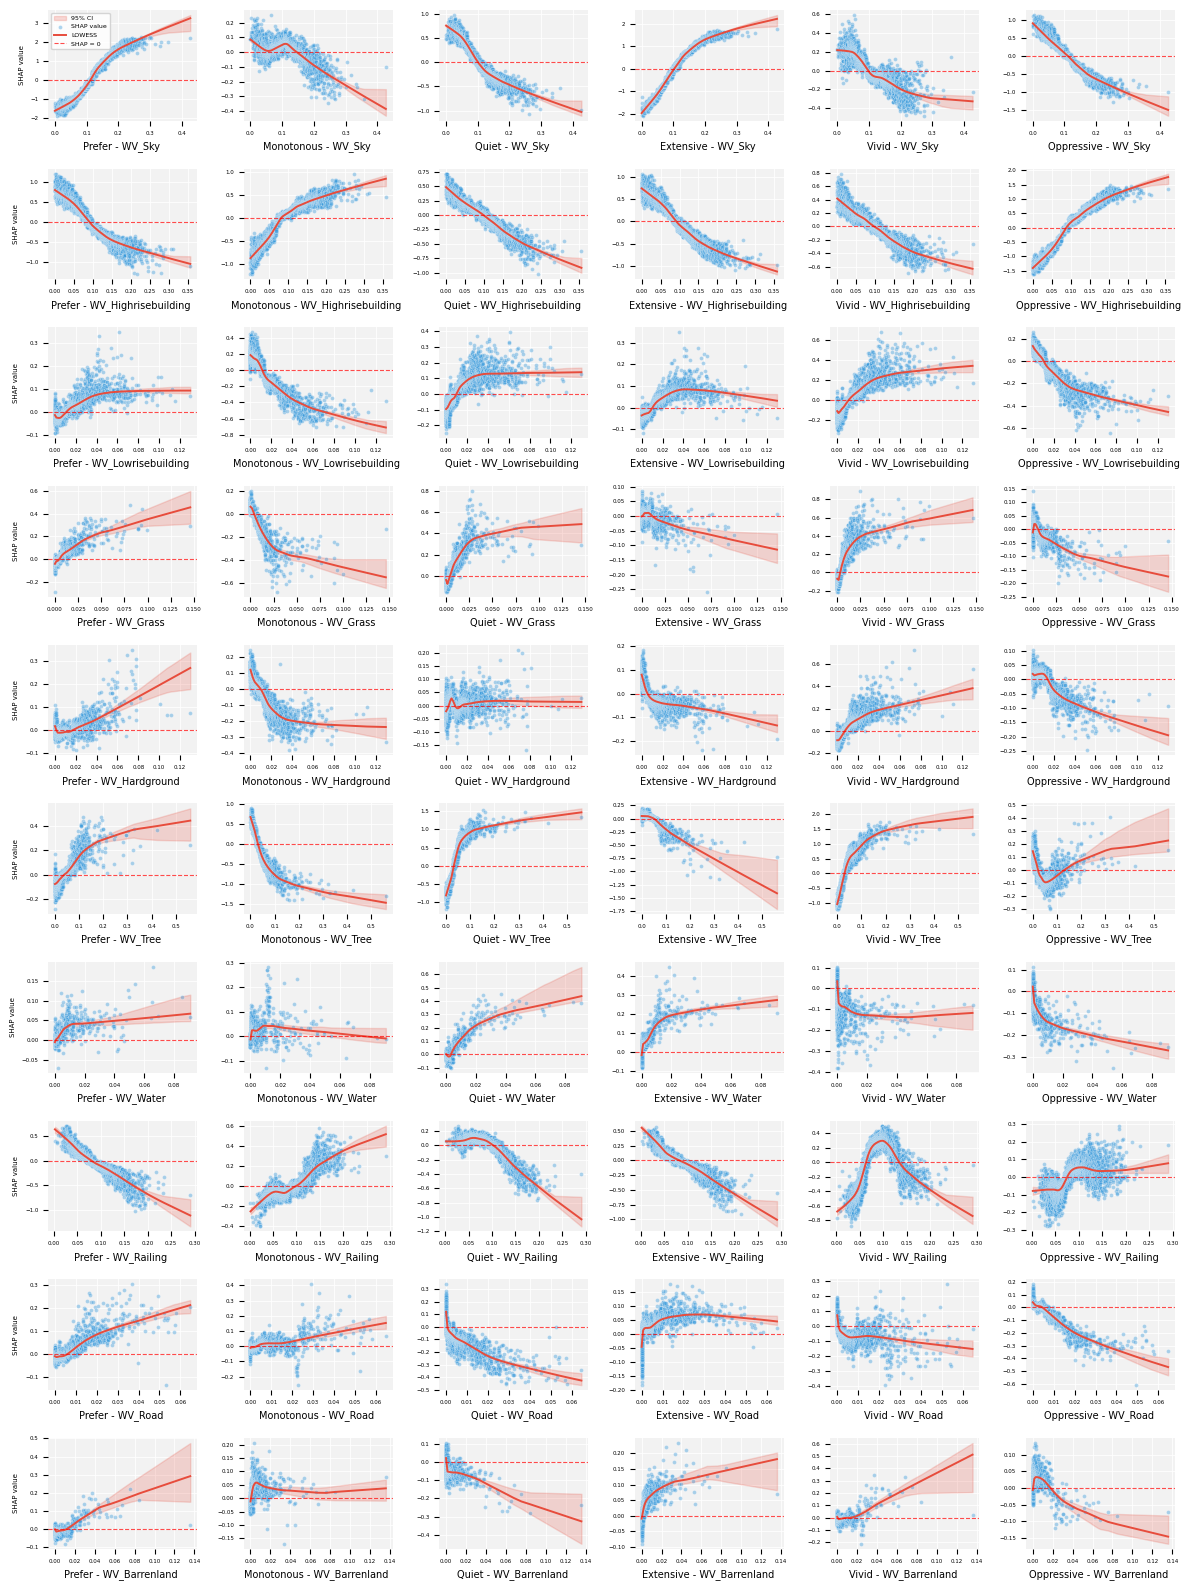

In [4]:
# (2) All perceptions × each window-view (WV) variable, one figure
group_cols = wv_cols
n_rows = len(group_cols)
n_cols = len(perception_cols)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 2.0, max(1.4, n_rows * 1.6)),
    squeeze=False,
)
for r, feature in enumerate(group_cols):
    for c, target in enumerate(perception_cols):
        plot_dependence(
            axes[r, c], target, feature,
            show_legend=(r == 0 and c == 0), show_ylabel=(c == 0),
            xlabel_fs=7, ylabel_fs=5, tick_fs=4, legend_fs=4.5,
        )

plt.tight_layout()
savefig_all(fig, str(group_fig_dir / 'shap_lowess_WV_all'))
plt.show()

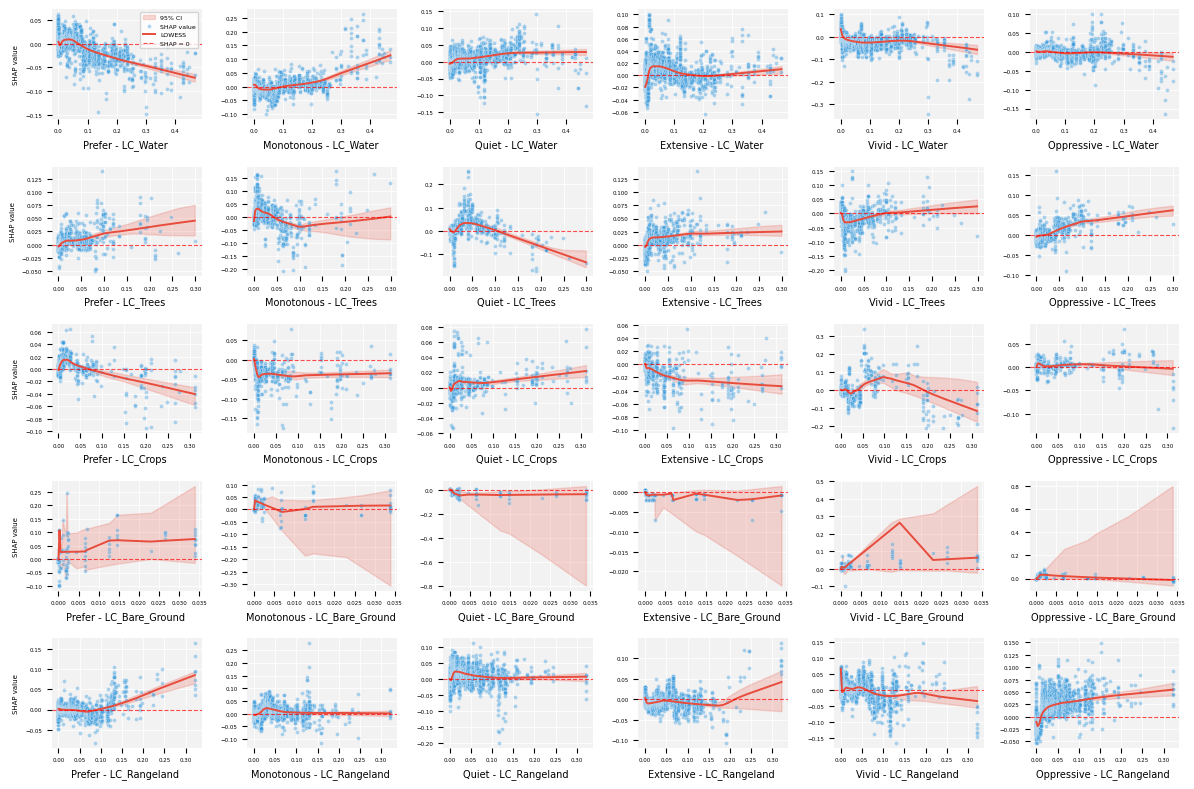

In [37]:
# (3) All perceptions × each land-cover (LC) variable, one figure
group_cols = lc_cols
n_rows = len(group_cols)
n_cols = len(perception_cols)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 2.0, max(1.4, n_rows * 1.6)),
    squeeze=False,
)
for r, feature in enumerate(group_cols):
    for c, target in enumerate(perception_cols):
        plot_dependence(
            axes[r, c], target, feature,
            show_legend=(r == 0 and c == 0), show_ylabel=(c == 0),
            xlabel_fs=7, ylabel_fs=5, tick_fs=4, legend_fs=4.5,
        )

plt.tight_layout()
savefig_all(fig, str(group_fig_dir / 'shap_lowess_LC_all'))
plt.show()

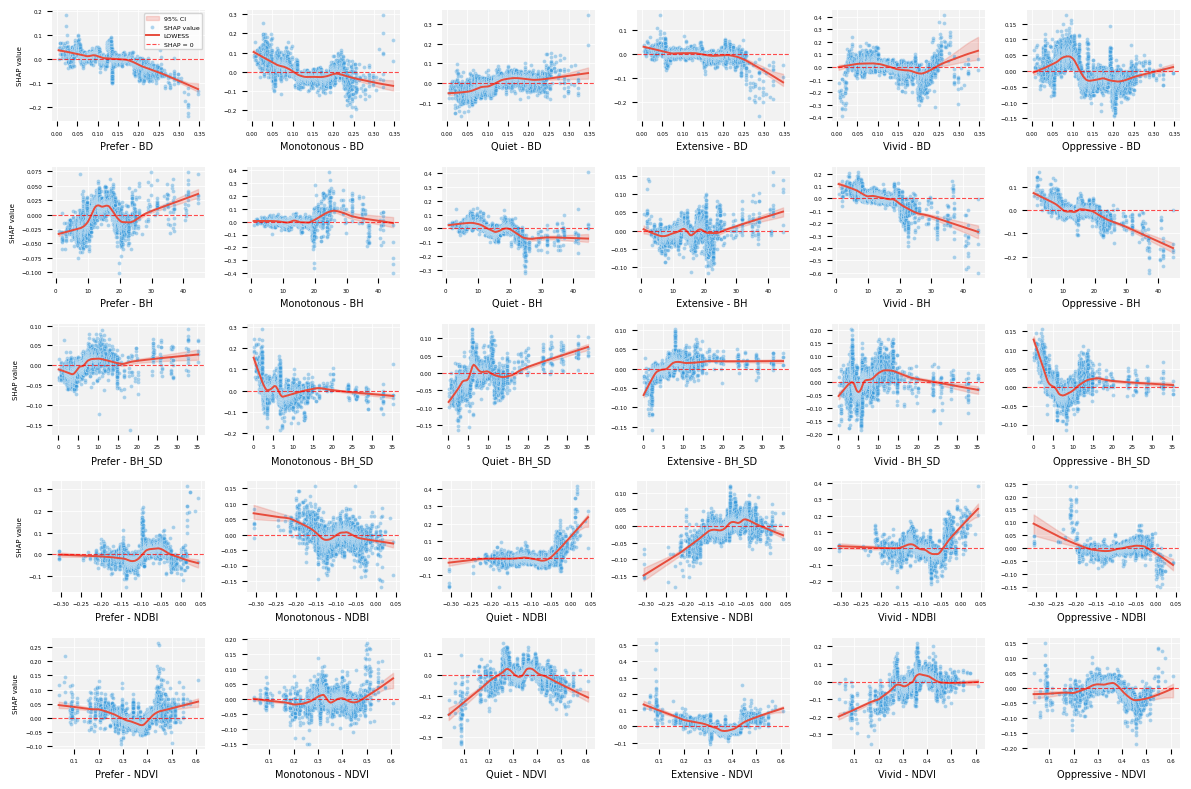

In [38]:
# (4) All perceptions × each urban-form variable, one figure
group_cols = urban_cols
n_rows = len(group_cols)
n_cols = len(perception_cols)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 2.0, max(1.4, n_rows * 1.6)),
    squeeze=False,
)
for r, feature in enumerate(group_cols):
    for c, target in enumerate(perception_cols):
        plot_dependence(
            axes[r, c], target, feature,
            show_legend=(r == 0 and c == 0), show_ylabel=(c == 0),
            xlabel_fs=7, ylabel_fs=5, tick_fs=4, legend_fs=4.5,
        )

plt.tight_layout()
savefig_all(fig, str(group_fig_dir / 'shap_lowess_urban_all'))
plt.show()

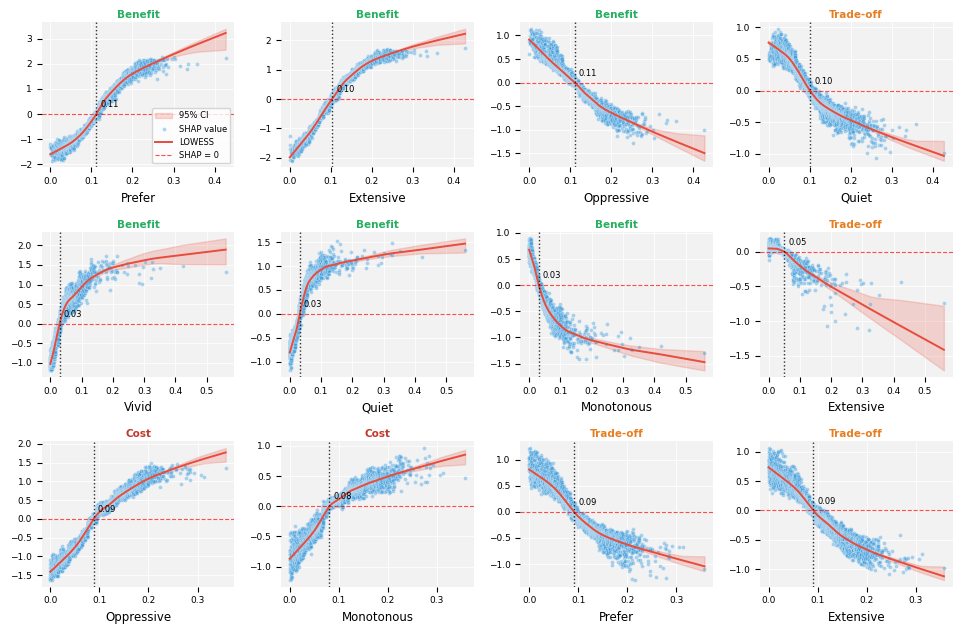

In [10]:
# (5) Key non-linear panels for the manuscript discussion figure (fig_non_linear)
# Rows = the three dominant view elements (largest LOWESS SHAP effect ranges).
# Columns = for each element, its four strongest perception dimensions
# (by SHAP amplitude, max-min of the LOWESS curve), ordered from benefits
# (left) to trade-offs / sign flips (right).
# Vertical dotted lines mark where the LOWESS SHAP curve crosses zero.
# Each panel carries a (target, tag) pair; the tag is drawn as a small
# colour-coded title above the panel (Benefit / Cost / Trade-off).
GRID = [
    ('WV_Sky',              [('Prefer', 'Benefit'), ('Extensive', 'Benefit'),
                             ('Oppressive', 'Benefit'), ('Quiet', 'Trade-off')]),
    ('WV_Tree',             [('Vivid', 'Benefit'), ('Quiet', 'Benefit'),
                             ('Monotonous', 'Benefit'), ('Extensive', 'Trade-off')]),
    ('WV_Highrisebuilding', [('Oppressive', 'Cost'), ('Monotonous', 'Cost'),
                             ('Prefer', 'Trade-off'), ('Extensive', 'Trade-off')]),
]
TAG_COLORS = {'Benefit': '#27ae60', 'Cost': '#c0392b', 'Trade-off': '#e67e22'}

def zero_crossings(target, feature):
    r = lowess_results[(target, feature)]
    x, y = np.asarray(r['x_lowess']), np.asarray(r['y_lowess'])
    idx = np.where(np.diff(np.sign(y)) != 0)[0]
    return [float(x[i]) for i in idx]

# y-axis titles intentionally omitted (annotated manually in post-processing)
fig, axes = plt.subplots(3, 4, figsize=(DOUBLE_COL_WIDTH * 1.35, FIG_HEIGHT_MEDIUM * 2.3))
for row, (feature, targets) in enumerate(GRID):
    for col, (target, tag) in enumerate(targets):
        ax = axes[row, col]
        plot_dependence(ax, target, feature, show_legend=False,
                        show_ylabel=False, xlabel_fs=7.5, ylabel_fs=7, tick_fs=6.5)
        ax.set_xlabel(target, fontsize=8.5)
        ax.set_title(tag, fontsize=7.5, fontweight='bold',
                     color=TAG_COLORS[tag], pad=3)
        xcs = zero_crossings(target, feature)
        if xcs:
            xc = xcs[0]
            ax.axvline(xc, color='black', linestyle=':', linewidth=1.0, alpha=0.8)
            ax.annotate(f'{xc:.2f}', xy=(xc, 0), xytext=(3, 5),
                        textcoords='offset points', fontsize=6)
axes[0, 0].legend(fontsize=6, frameon=True)
plt.tight_layout()
savefig_all(fig, str(group_fig_dir / 'shap_lowess_selected_pairs'))
plt.show()